In [1]:
import pandas as pd
df = pd.read_csv('sales_data_12k.csv')

In [6]:
df['revenue'] = df['price']* df['quantity']
df['profit'] = (df['price'] - df['cost']) * df['quantity']
df.head(3)

,order_id,order_date,customer_id,city,product,category,quantity,price,cost,revenue,profit
0,1001,2025-01-25,C223,Bangalore,Chair,Furniture,3,7000,5000,21000,6000
1,1002,2025-04-18,C238,Gurgaon,Laptop,Electronics,3,55000,48000,165000,21000
2,1003,2025-03-24,C264,Pune,Table,Furniture,2,12000,9000,24000,6000


In [11]:
# Total Sales
total_sales = df['revenue'].sum()
total_sales
# Total Profit 
total_profit = df['profit'].sum()
total_profit

# City Wise revenue 
city_revenue = df.groupby('city')['revenue'].sum().sort_values(ascending=False)
city_revenue

city
Mumbai       63133400
Gurgaon      62541500
Pune         60986600
Bangalore    59410700
Delhi        58345500
Noida        56322100
Name: revenue, dtype: int64

In [28]:
# Top Products 
top_products = df.groupby('product')['revenue'].sum().sort_values(ascending=False)
top_products

# Monthly Trend
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.to_period('M')
monthly_revenue = df.groupby('month')['revenue'].sum()
monthly_revenue

month
2025-01    95173900
2025-02    80900400
2025-03    95547300
2025-04    85673300
2025-05     3444900
Freq: M, Name: revenue, dtype: int64

In [27]:
# Top Customers 
top_customers = df.groupby('customer_id')['revenue'].sum().sort_values(ascending=False).head(10)
top_customers

# Product Profitabiliy 
product_profit = df.groupby('product')['profit'].sum().sort_values(ascending=False)
product_profit
# Category Revenue 
category_revenue = df.groupby('category')['revenue'].sum().sort_values(ascending=False)
category_revenue

# city Profit
city_profit = df.groupby('city')['profit'].sum().sort_values(ascending=False)
city_profit

# Pivot table
pivot_table = df.pivot_table(values='revenue', index='city', columns='category', aggfunc='sum')
pivot_table

category,Electronics,Furniture
city,,
Bangalore,46283700,13127000
Delhi,46440500,11905000
Gurgaon,49750500,12791000
Mumbai,50788400,12345000
Noida,43875100,12447000
Pune,48039600,12947000


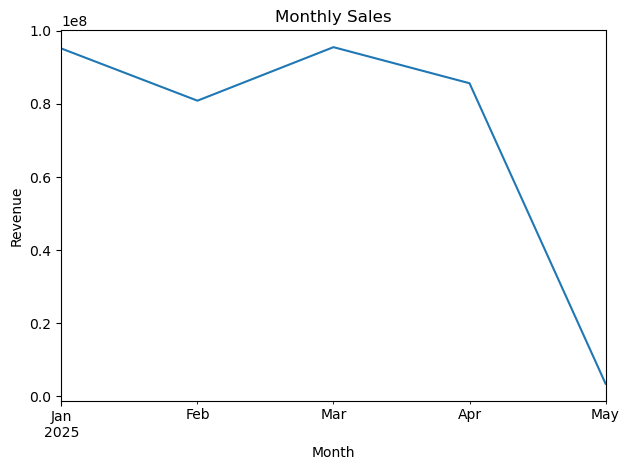

In [31]:
# Monthly Sale charts
import matplotlib.pyplot as plt
monthly_revenue.plot(kind='line')
plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()


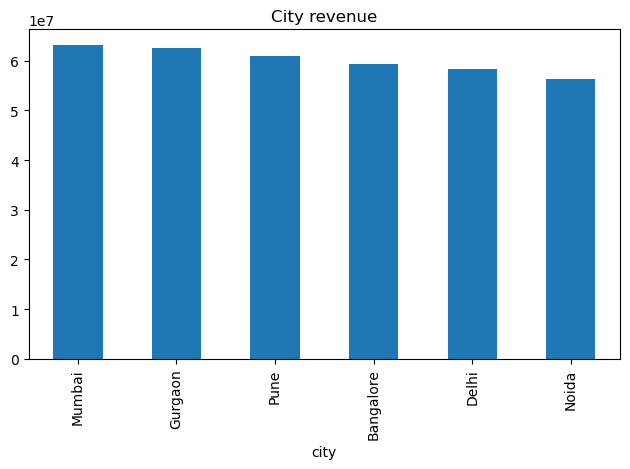

In [34]:
# City Revenue Chart 
city_revenue.plot(kind='bar')
plt.title('City revenue')
plt.tight_layout()
plt.show()

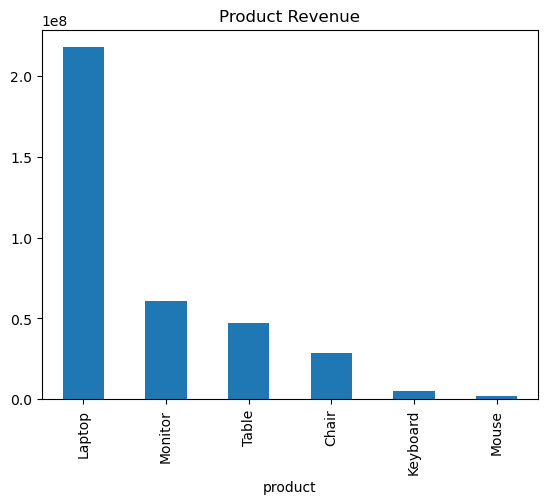

In [36]:
# Product Revenue 
top_products.plot(kind='bar')
plt.title('Product Revenue')
plt.show()

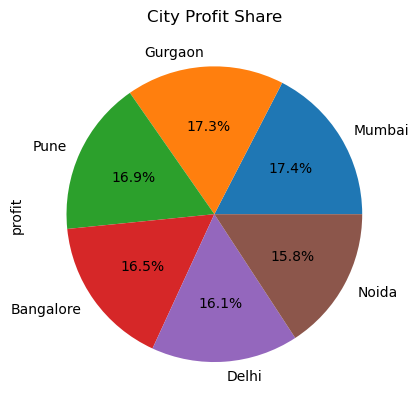

In [38]:
# Profit Distribution 
city_profit.plot(kind='pie', autopct = '%1.1f%%')
plt.title('City Profit Share')
plt.show()

In [39]:
df.to_csv('final_sales_report.csv', index = False)

In [44]:
# Average order value 
aov = df['revenue'].sum() / df['order_id'].nunique()
print('Average Order Value : ', aov)

Average Order Value :  30061.65


In [45]:
# Profit Margin 
profit_margin = (df['profit'].sum() / df['revenue'].sum())*100
print('Profit margin : ', profit_margin)

Profit margin :  17.22621124699853
